## CS441: Applied ML - HW 3

## Part 1: Spam Detection with Naive Bayes Classifier

We want to classify text messages as “spam” (unwanted) or “ham” (genuine). We will use data (spam.csv) from the Kaggle SMS spam dataset. We’ve provided the loading and pre-processing code to generate:
* `unique_words`: the unique set of words in the dataset
* `(x_train, y_train, msg_train)`: counts of words in each message, spam (y=1) or not spam (y=-1) labels, and the message string for each training sample; `x_train[n][j]` is the count of the `j`th word in the `n`th sample.
* `*_val` and `*_test`, similar to above, for the val and test splits
We will use a Naive Bayes Classifier.

See assignment for details (equations are not easy to reproduce here).

In [1]:
import csv
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

# from google.colab import drive
# drive.mount('/content/drive')
datadir = "../data/" # choose proper location

# don't change the code below

# read data
with open(datadir + 'spam.csv', encoding='latin-1') as csvfile:
    datareader = csv.reader(csvfile, delimiter=',')
    y = np.zeros((10000,))
    X = []
    n = 0
    rownum = 0
    for row in datareader:
      if rownum == 0:
        rownum += 1
        continue
      rownum += 1
      if row[0]=='ham':
        y[n] = -1
      else:
        y[n] = 1
      X.append(row[1])
      n += 1
y= y[:n]

# y[n] = -1 for ham, 1 for spam
print(y[0])
print(X[0])

# parse the text messages into words and count the words in each row
vectorizer = CountVectorizer(analyzer='word')
word_count = vectorizer.fit_transform(X).toarray()

print(f"We have {word_count.shape[0]} examples with {word_count.shape[1]} unique words.")
unique_words = vectorizer.get_feature_names_out()

# split data into train (50%), validation (25%), and test (25%)
x_train = word_count[::2]
y_train = y[::2]
msg_train = X[::2]
x_val = word_count[1::4]
y_val = y[1::4]
msg_val = X[1::4]
x_test = word_count[3::4]
y_test = y[3::4]
msg_test = X[3::4]


-1.0
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
We have 5572 examples with 8672 unique words.


#### 1. Train your Naive Bayes Classifier
I.e. P(y), P(w|y)) using the train set with =1 and compute the accuracy on the val set.  You should get P(y=1)=0.142, P(call|spam) = 0.0104, and P(call|ham)=0.0029. Your validation accuracy should be higher than 95%.

In [2]:
# TO DO
from sklearn.naive_bayes import MultinomialNB
gb = MultinomialNB()
gb.fit(x_train, y_train)
call_idx = np.where(unique_words == "call")
call_idx = call_idx[0][0]

print(np.exp(gb.feature_log_prob_[0, call_idx]))
print(np.exp(gb.feature_log_prob_[1, call_idx]))


gb.score(x_val, y_val)

0.0028976666158304085
0.010444010053057812


0.9813352476669059

#### 2. Data exploration
What are the 10 spammiest words (i.e. words with highest  logP(wj|spam)- logP(wj|ham))?  What are the 10 hammiest words? Which val message is the spammiest ham (message with highest spam score but y=-1)? Which is hammiest spam (message with lowest spam score but y=1)?  Spammiest spam? Hammiest ham?

In [3]:
# TO DO
def ham_given_word(word):
    word_idx = np.where(unique_words == word)
    word_idx = word_idx[0][0]
    return np.exp(gb.feature_log_prob_[0, word_idx])

def spam_given_word(word):
    word_idx = np.where(unique_words == word)
    word_idx = word_idx[0][0]
    return np.exp(gb.feature_log_prob_[1, word_idx])

#I think these two functions capture the spirit. Bye


#### 3. Precision-recall trade-off
You want to flag spam messages with minimal false positives. Using the val set, compute precision/recall and display the PR curve. Programmatically, find the threshold with highest recall, where precision > 0.99.  Report the accuracy, precision, and recall on the test set using the same model and the selected threshold.

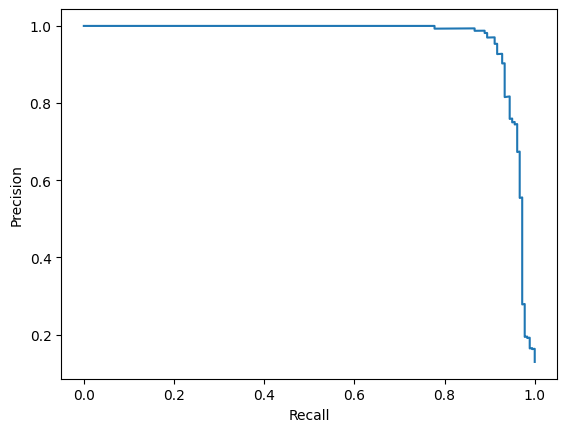

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve


# TO DO
precision, recall, thresholds = precision_recall_curve(y_val, gb.predict_proba(x_val)[:, 1])
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()



## Part 2: Robust Estimation

The corrupted salary dataset has three variables: salary, years, school.  Salary is the reported salary of each person.  Years is the number of years of experience in the job.  School is the university where the person last had a degree. For the core assignment, we’ll only use salary, and the stretch goals will use the other two variables. Some of the reported salary information is wrong (some incorrect value is provided), so we want to learn things from the data in a way that is robust to the wrong data. We refer to correctly entered data as “valid”.

Estimate the true mean, standard deviation, min, and max of the salaries using three different methods.

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
datadir = "../data/"

# load data
T = np.load(datadir + 'salary.npz')
(salary, years, school) = (T['salary'], T['years'], T['school'])

#### 1. Assume no noise
Compute the statistics for the data as a whole

In [ ]:
# TO DO

print('Mean: {}  Std: {}  Min: {}   Max: {}'.format(salary_mu, salary_std, salary_min, salary_max))

#### 2. Percentiles
Assume valid data will fall between the 5th and 95th percentile. Adjust estimates of the min and max by assuming that the valid data has a uniform distribution (see lecture on robust fitting).

In [ ]:
pct = 0.05

# TO DO

print('Mean: {}  Std: {}  Min: {}   Max: {}'.format(salary_mu, salary_std, salary_min, salary_max)

#### 3. EM
Assume valid data follows a Gaussian distribution, while the fake data has a uniform distribution between the minimum and maximum value of salary. For mean and std, report the estimated mean and std of the valid salary distribution. For min and max, report the min and max salaries that have greater than 50% chance of being valid. Also report the estimated probability that a random sample is valid, and the first five indices of salaries that are not likely to be valid.

In [ ]:

# TO DO


print('Mean: {}  Std: {}  Min: {}   Max: {}'.format(salary_mu, salary_std, salary_min, salary_max)

# print the first five indices of salaries that are not likely to be valid
print(np.where(p_valid_given_s<0.5)[0][:5])

## Part 3: Stretch Goals
Include all your code used for any stretch goals in this section. Add headings where appropriate.

In [ ]:
# TO DO (optional)

In [ ]:
# from https://gist.github.com/jonathanagustin/b67b97ef12c53a8dec27b343dca4abba
# install can take a minute

import os
# @title Convert Notebook to PDF. Save Notebook to given directory
NOTEBOOKS_DIR = "/content/drive/MyDrive/CS441/hw2" # @param {type:"string"}
NOTEBOOK_NAME = "CS441_HW2_Solution.ipynb" # @param {type:"string"}
#------------------------------------------------------------------------------#
from google.colab import drive
drive.mount("/content/drive/", force_remount=True)
NOTEBOOK_PATH = f"{NOTEBOOKS_DIR}/{NOTEBOOK_NAME}"
assert os.path.exists(NOTEBOOK_PATH), f"NOTEBOOK NOT FOUND: {NOTEBOOK_PATH}"
!apt install -y texlive-xetex texlive-fonts-recommended texlive-plain-generic > /dev/null 2>&1
!jupyter nbconvert "$NOTEBOOK_PATH" --to pdf > /dev/null 2>&1
NOTEBOOK_PDF = NOTEBOOK_PATH.rsplit('.', 1)[0] + '.pdf'
assert os.path.exists(NOTEBOOK_PDF), f"ERROR MAKING PDF: {NOTEBOOK_PDF}"
print(f"PDF CREATED: {NOTEBOOK_PDF}")